In [98]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
# from uncertainties import ufloat
# import uncertainties
# from uncertainties.umath import *
pd.set_option('future.no_silent_downcasting', True)

In [99]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [100]:
folder = Path('../../data/5_interactions/')

spent_mannose_fn = folder / 'cfus_spent_mannose.csv'
fresh_mannose_fn = folder / 'cfus_fresh_mannose.csv'
spent_malate_fn = folder / 'cfus_spent_malate.csv'
fresh_malate_fn = folder / 'cfus_fresh_malate.csv'

files = [spent_mannose_fn, fresh_mannose_fn, spent_malate_fn, fresh_malate_fn]
dfs = []
for fn in files:
    df = pd.read_csv(fn, index_col=0)
    if 'spent' in str(fn):
        df['spent'] = True
    else:
        df['spent'] = False
    dfs.append(df)
df = pd.concat(dfs)

In [101]:
df.Medium.unique()

array([nan, 'Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No_CS',
       'At_mannose', 'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At-malate', 'Ct-malate', 'Ml-malate',
       'Oa-malate', 'No-CS', 'M9-malate', 'M9-malate+thiamine',
       'M9-malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [102]:
# Remove nan rows
df.dropna(subset=['CFUs/mL', 'Medium'], inplace=True)
# df.loc[(df.Medium.isna())].iloc[40:80]

In [103]:
# Remove inoculum wells
df = df.loc[df['Well'] != 'Inoculum']

# Remove nan rows
df = df.dropna(subset=['CFUs/mL'])

df.replace(['No_CS', 'No-CS'], 'No CS', inplace=True)
df['Medium'] = df['Medium'].str.replace('-', '_')

df['Base carbon source'] = [x.split('+')[0].capitalize() if isinstance(x, str) else 'No CS'  for x in  df.Medium.str.replace('_','-').str.split('-').str[1]]

df.reset_index(drop=True, inplace=True)
df.head()

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,Base carbon source
0,B10,2,200000000.0,At,At+Ct,Ml_mannose,0.001,True,Mannose
1,C11,2,300000000.0,At,At+Oa,Ml_mannose,0.001,True,Mannose
2,D1,2,520000000.0,At,At,Ct_isoleucine,0.001,True,Isoleucine
3,D4,2,260000000.0,At,At+Ml,Ct_isoleucine,0.001,True,Isoleucine
4,D5,2,300000000.0,At,At+Oa,Ct_isoleucine,0.001,True,Isoleucine


In [104]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

In [105]:
print(df.Medium.unique())

df['Base carbon source'].unique()

for i, row in df.iterrows():
    if row['Medium'].split('_')[0] in ['At', 'Ct', 'Ml', 'Oa']:
        short_name = row['Medium'].split('_')[0]
        bg = row['Medium'].split('_')[0]
    elif row['Medium']=='No CS':
        short_name = 'No CS'
        bg = 'No CS'
    else:
        short_name = 'Fresh'
        bg = 'Fresh'
        if row['Medium'].split('+')[-1]=='thiamine':
            short_name += ' + T'
        elif row['Medium'].split('+')[-1]=='proline':
            short_name += ' + Vit. & AA'
    
    if '+' in row['Inoculated species']:
        partner = row['Inoculated species'].replace(row['Species'], '').replace('+', '')
        short_name += f' ({partner})'
    else:
        partner = 'No partner'
    
    if bg == 'Fresh':
        if '+' in row['Inoculated species']:
            bg += ' (coculture)'
        else:
            bg += ' (monoculture)'

    df.at[i, 'Short name'] = short_name
    df.at[i, 'Background'] = bg
    df.at[i, 'Partner'] = partner
    


['Ml_mannose' 'Ct_isoleucine' 'Oa_mannose' 'No CS' 'At_mannose'
 'M9_mannose' 'M9_mannose+thiamine'
 'M9_mannose+thiamine+biotin+cysteine+proline' 'M9_isoleucine'
 'M9_isoleucine+thiamine+biotin+cysteine+proline' 'M9_isoleucine+thiamine'
 'At_malate' 'Ct_malate' 'Ml_malate' 'Oa_malate' 'M9_malate'
 'M9_malate+thiamine' 'M9_malate+thiamine+biotin+cysteine+proline']


In [106]:
df.loc[(df.Medium == 'M9_isoleucine')&(df.Plate==3), 'Short name'] = 'Fresh'
df.loc[(df.Medium == 'No CS')&(df.Plate==3), 'Short name'] = 'No CS 2'
df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] =df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] + ' 2'


# Plot

In [107]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

# At

['Ml (Ct)' 'Ml (Oa)' 'Oa (Ml)' 'No CS' 'At' 'Ml' 'Oa' 'Oa (Ct)'
 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 16
16


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/1418475617.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


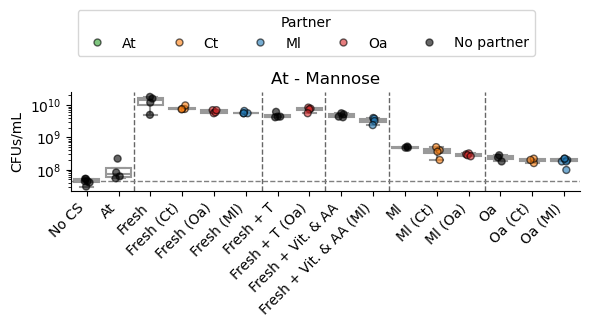

In [108]:
s = 'At'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
          'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
        #  'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]
partner_palette = {
    'At': 'C2',
    'Ct': 'C1',
    'Oa': 'C3',
    'Ml': 'C0',
    'No partner': 'k',
}
fig, ax = plt.subplots(figsize=(6, 4))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/4273028588.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


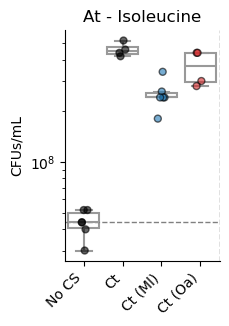

In [109]:
#Isoleucine

s = 'At'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]
fig, ax = plt.subplots(figsize=(2, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=3.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.6,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'No CS' 'Ct (Ml)' 'Ml (Ct)' 'Oa (Ct)' 'Ct (Oa)'
 'Ml (Oa)' 'Oa (Ml)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 19
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/4150745095.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


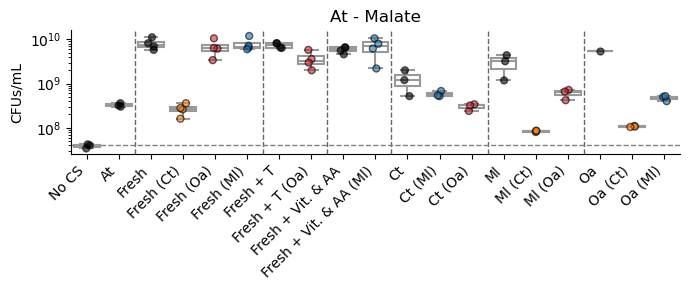

In [110]:
s = 'At'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
         'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5, 15.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ct

In [111]:
# df.loc[(df['Species']=='Ct')&(df['Base carbon source']=='Mannose')&(df['Short name']=='Fresh + T'), 'CFUs/mL'] *= 10

['At' 'At (Ml)' 'At (Oa)' 'Ml' 'Ml (At)' 'Oa' 'Oa (Ml)' 'No CS' 'Ml (Oa)'
 'Oa (At)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/2336812910.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


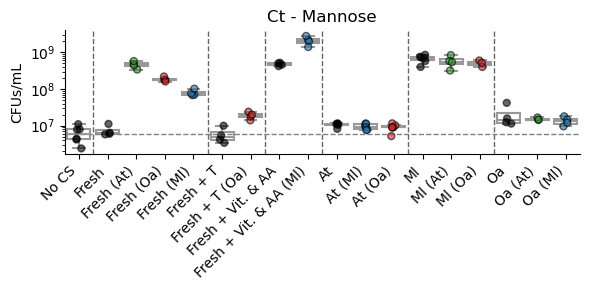

In [112]:
s = 'Ct'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['No CS' 'Ct' 'Ct 2' 'Fresh' 'No CS 2'] 5


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/276072428.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


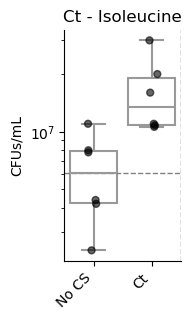

In [113]:
#Isoleucine

s = 'Ct'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2,3]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(1.5, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=1.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.5,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'At (Ml)' 'Ml (At)' 'Oa (At)' 'At (Oa)' 'Ml (Oa)'
 'Oa (Ml)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/56239609.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


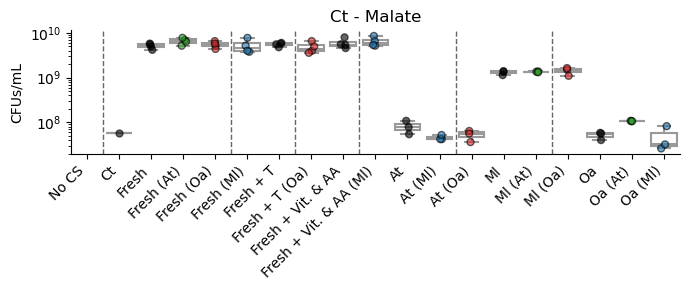

In [114]:
s = 'Ct'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ct',
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ml

['At' 'At (Ct)' 'At (Oa)' 'Oa (At)' 'Oa (Ct)' 'No CS' 'Ml' 'Oa'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/1340682351.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


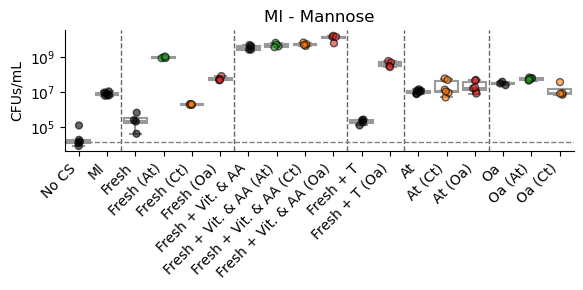

In [115]:
s = 'Ml'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Oa)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/495419047.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


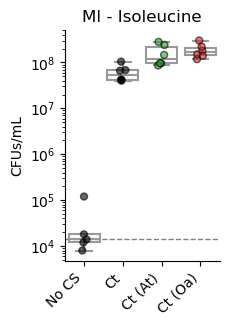

In [116]:
#Isoleucine

s = 'Ml'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + Vit. & AA',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Oa)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Oa (At)' 'At (Oa)'
 'Ct (Oa)' 'Oa (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh + T' 'Fresh + Vit. & AA' 'Fresh'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/4137059761.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


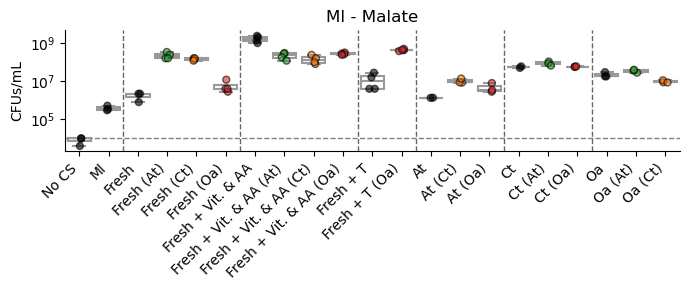

In [117]:
s = 'Ml'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

         'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Oa

['At' 'At (Ct)' 'At (Ml)' 'Ml' 'Ml (At)' 'No CS' 'Oa' 'Ml (Ct)'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh + T (At)' 'Fresh + T (Ct)'
 'Fresh + T (Ml)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/1360809093.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


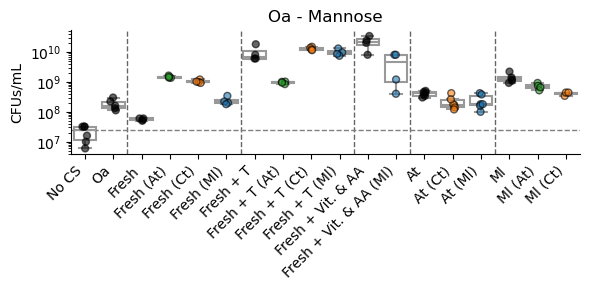

In [118]:
s = 'Oa'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)',
        



         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Ml)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/578865198.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


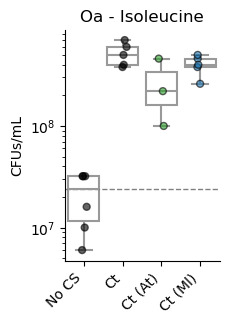

In [119]:
#Isoleucine

s = 'Oa'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + T',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Ml)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Ml (At)' 'At (Ml)'
 'Ct (Ml)' 'Ml (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)'
 'Fresh + T (At)' 'Fresh + T (Ct)' 'Fresh + T (Ml)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/3678094694.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


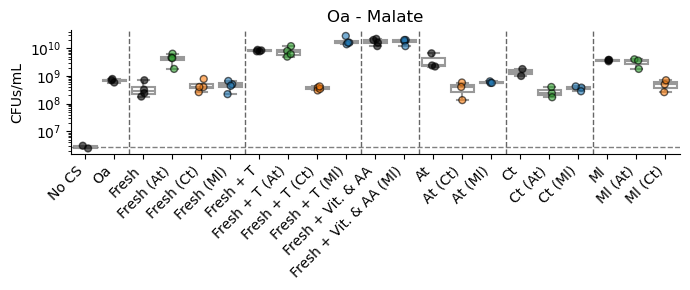

In [120]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

         'Ct', 'Ct (At)', 'Ct (Ml)',
         'Ml', 'Ml (At)', 'Ml (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

## All species together - malate

32


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/3539817016.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


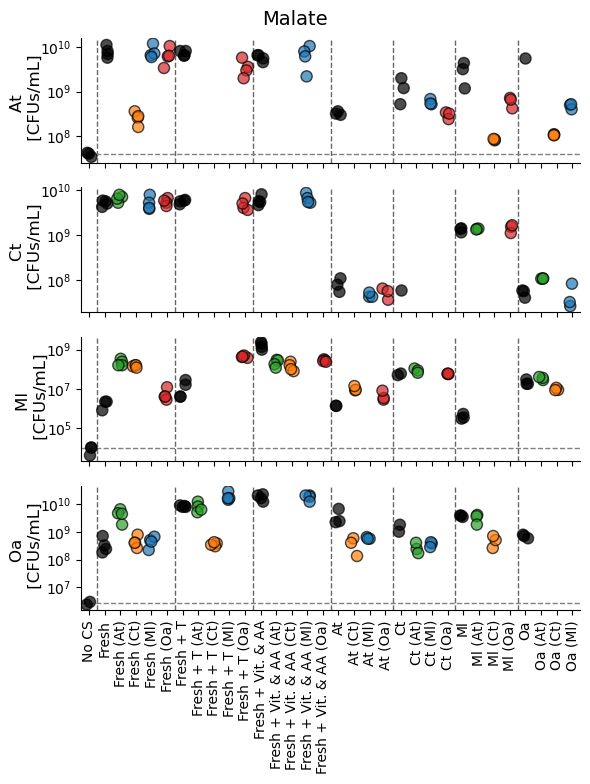

In [121]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(6,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

## Mannose

28


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1436/2614116191.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


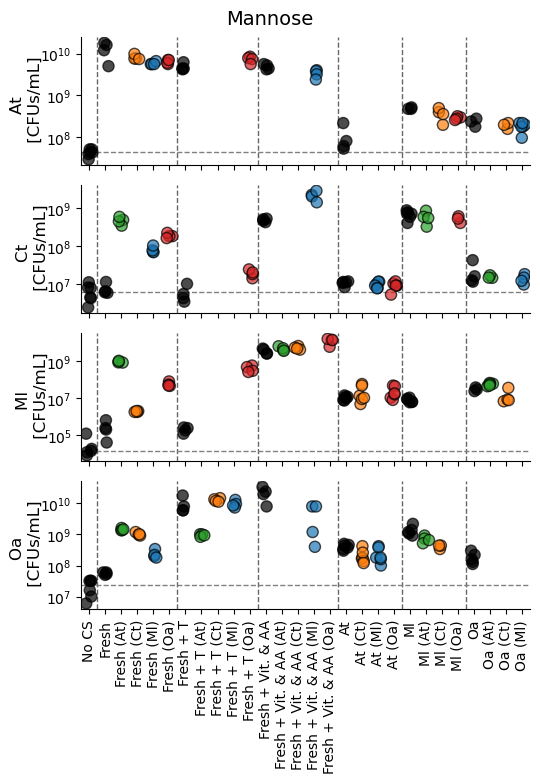

In [122]:
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
        #  'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(5.5,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    legend = False
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

# All species spent only


5


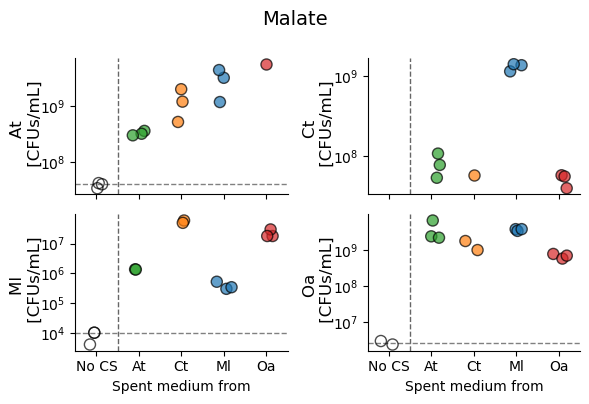

In [123]:
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

5


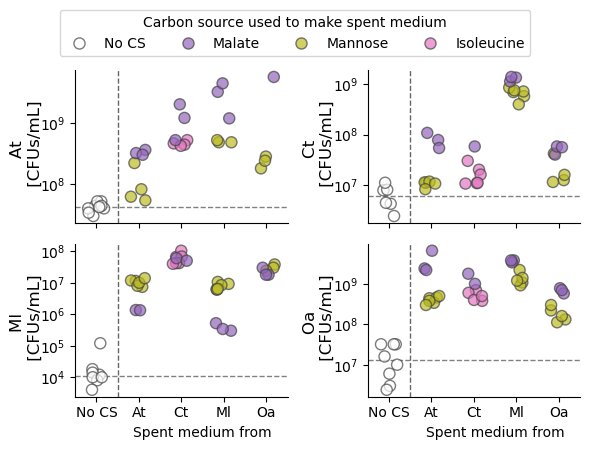

In [124]:
cs = 'Mannose'
bcs = ['Malate', cs, 'Isoleucine', 'No CS']
plates = [2, 4]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
        #  'Ct'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    # sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    if i == 3:
        legend = True
    else:
        legend = False
    # legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    # hue='Short name',
                    hue = 'Base carbon source',
                    # palette=partner_palette, 
                    palette = {'No CS':'w', 'Malate': 'C4','Mannose': 'C8', 'Isoleucine': 'C6'},
                    hue_order=['No CS', 'Malate', 'Mannose','Isoleucine'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from', x = 0.6)
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
# fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=True, title = "Carbon source used to make spent medium", title_fontsize=10, fontsize=10)
# Remove legend from last subplot
axes[3].get_legend().remove()

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

In [125]:
df.loc[df['Short name'].isin(['No CS', ])].sort_values(by = 'Species')

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,Base carbon source,Short name,Background,Partner
10,G1,2,44000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
11,G2,2,52000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
12,G3,2,52000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
403,E3,4,34000000.0,At,At,No CS,NaN,True,No CS,No CS,No CS,No partner
402,E2,4,40000000.0,At,At,No CS,NaN,True,No CS,No CS,No CS,No partner
401,E1,4,42000000.0,At,At,No CS,NaN,True,No CS,No CS,No CS,No partner
116,G3,2,44000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
115,G2,2,40000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
114,G1,2,30000000.0,At,At,No CS,0.001,True,No CS,No CS,No CS,No partner
148,G6,2,4400000.0,Ct,Ct,No CS,0.001,True,No CS,No CS,No CS,No partner


In [126]:
# bcs = ['Malate', cs, 'Isoleucine', 'No CS']
# plates = [2,4, 5, 6]
# # print(sn, len(sn))
# order = ['No CS', 'At', 'Ct', 'Ml', 'Oa']
# df_spent_dist = 
# for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
#     sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))


2


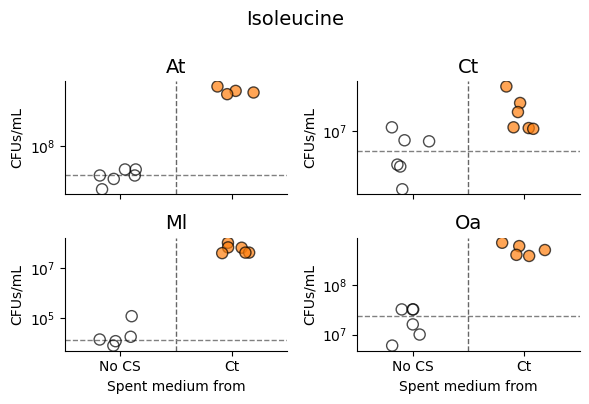

In [127]:
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
        #  'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
        #  'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
        #  'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

# Save data


In [128]:
df.to_csv(folder/'all_interactions_cfus.csv')